Feature shape: (200, 4)
Label shape: (200,)

Classical SVM Accuracy:
Train: 0.81
Test : 0.80

Classical SVM Metrics (Train):
              precision    recall  f1-score   support

           0       0.81      1.00      0.90       130
           1       0.00      0.00      0.00        30

    accuracy                           0.81       160
   macro avg       0.41      0.50      0.45       160
weighted avg       0.66      0.81      0.73       160


Classical SVM Metrics (Test):
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        32
           1       0.00      0.00      0.00         8

    accuracy                           0.80        40
   macro avg       0.40      0.50      0.44        40
weighted avg       0.64      0.80      0.71        40


Confusion Matrix:
[[32  0]
 [ 8  0]]


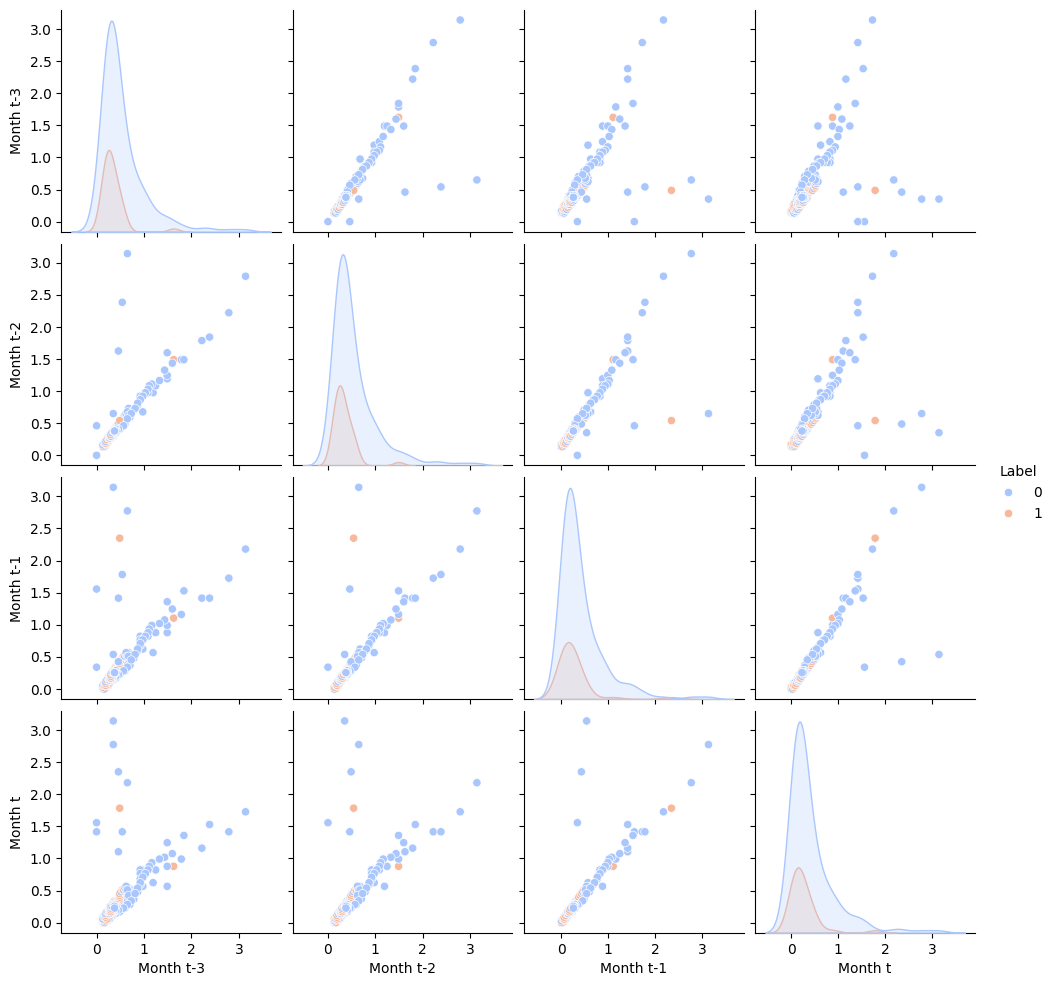

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.svm import SVC


df = pd.read_csv("unemployment_msa_2020_2026.csv")

# Keep only needed columns
df = df.drop(columns=["Series ID", "Series Name", "Units", "Region Code"])

# Convert wide → long format
df_long = df.melt(
    id_vars=["Region Name"],
    var_name="Date",
    value_name="Unemployment"
)

# Convert types
df_long["Date"] = pd.to_datetime(df_long["Date"])
df_long["Unemployment"] = pd.to_numeric(df_long["Unemployment"], errors="coerce")

# Sort + forward fill missing values
df_long = df_long.sort_values(["Region Name", "Date"])
df_long["Unemployment"] = df_long.groupby("Region Name")["Unemployment"].ffill()
df_long["Next"] = df_long.groupby("Region Name")["Unemployment"].shift(-1)
df_long["Label"] = (df_long["Next"] > df_long["Unemployment"]).astype(int)


# Create sliding windows
window_size = 4
x = []
y = []

for region in df_long["Region Name"].unique():
    sub = df_long[df_long["Region Name"] == region].sort_values("Date")

    values = sub["Unemployment"].values
    labels = sub["Label"].values

    for i in range(len(values) - window_size - 1):
        x.append(values[i:i+window_size])
        y.append(labels[i+window_size]) 

x = np.array(x)
y = np.array(y)

# Remove bad data (NaNs)
valid = ~np.any(np.isnan(x), axis=1) & ~np.isnan(y)
x = x[valid]
y = y[valid]

# limiting size for speed (given more training time, can remove this)
x = x[:200]
y = y[:200]

print("Feature shape:", x.shape)
print("Label shape:", y.shape)


# scale data appropriately
scaler = MinMaxScaler(feature_range=(0, np.pi))
features = scaler.fit_transform(x)
labels = y


# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    features, labels, train_size=0.8, random_state=123, stratify=labels
)


# Classical SVM baseline
svc = SVC()
svc.fit(X_train, y_train)

train_acc = svc.score(X_train, y_train)
test_acc = svc.score(X_test, y_test)

print(f"\nClassical SVM Accuracy:")
print(f"Train: {train_acc:.2f}")
print(f"Test : {test_acc:.2f}")



# METRICS + VISUALIZATION
preds = svc.predict(X_test)
preds_train = svc.predict(X_train)

print("\nClassical SVM Metrics (Train):")
print(classification_report(y_train, preds_train, zero_division=0))
print("\nClassical SVM Metrics (Test):")
print(classification_report(y_test, preds, zero_division=0))

cm = confusion_matrix(y_test, preds)
print("\nConfusion Matrix:")
print(cm)


df_vis = pd.DataFrame(features, columns=[
    "Month t-3", "Month t-2", "Month t-1", "Month t"
])
df_vis["Label"] = labels

sns.pairplot(df_vis, hue="Label", palette="coolwarm")
plt.show()


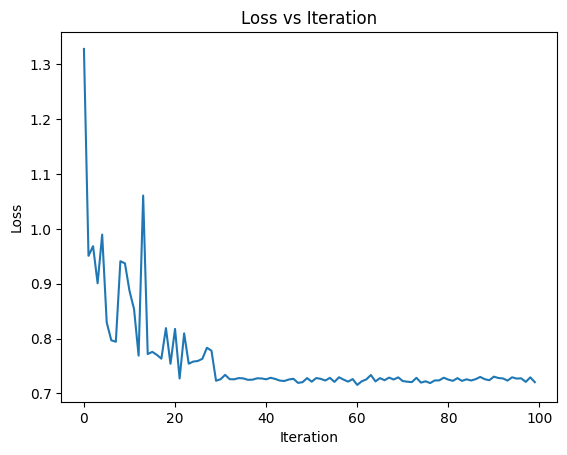

Training time: 70 seconds
Quantum VQC Train: 0.80
Quantum VQC Test : 0.78

Quantum VQC Metrics (Train):
              precision    recall  f1-score   support

           0       0.82      0.98      0.89       130
           1       0.40      0.07      0.11        30

    accuracy                           0.81       160
   macro avg       0.61      0.52      0.50       160
weighted avg       0.74      0.81      0.75       160


Quantum VQC Metrics (Test):
              precision    recall  f1-score   support

           0       0.79      0.94      0.86        32
           1       0.00      0.00      0.00         8

    accuracy                           0.75        40
   macro avg       0.39      0.47      0.43        40
weighted avg       0.63      0.75      0.69        40



In [ ]:
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.algorithms.classifiers import VQC

import time
from IPython.display import clear_output

# Set up feature map and ansatz
num_features = X_train.shape[1]

feature_map = ZZFeatureMap(feature_dimension=num_features, reps=1)
ansatz = RealAmplitudes(num_qubits=num_features, reps=3)
feature_map.decompose().draw(output="mpl", style="clifford", fold=20)
ansatz.decompose().draw(output="mpl", style="clifford", fold=20)

# optimize ry parameters
optimizer = COBYLA(maxiter=100)
sampler = Sampler()


# Loss Function: 
objective_func_vals = []

def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.plot(objective_func_vals)
    plt.title("Loss vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()


vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback_graph,
)

# build graph and train
start = time.time()
vqc.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Training time: {round(elapsed)} seconds")


# Metrics and evaluation
train_score_q = vqc.score(X_train, y_train)
test_score_q = vqc.score(X_test, y_test)
print(f"Quantum VQC Train: {train_score_q:.2f}")
print(f"Quantum VQC Test : {test_score_q:.2f}")

preds_train_q = vqc.predict(X_train)
preds_test_q = vqc.predict(X_test)
print("\nQuantum VQC Metrics (Train):")
print(classification_report(y_train, preds_train_q, zero_division=0))
print("\nQuantum VQC Metrics (Test):")
print(classification_report(y_test, preds_test_q, zero_division=0))

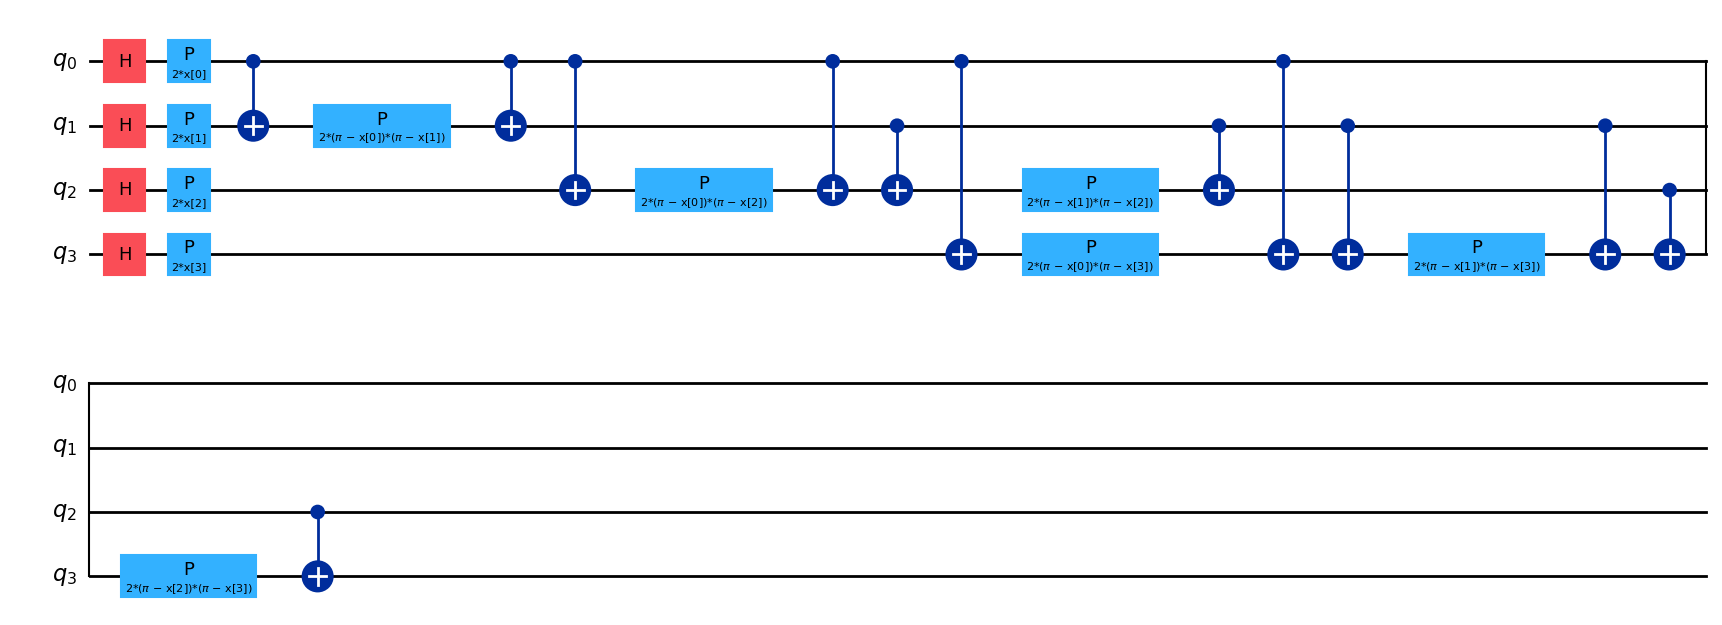

In [ ]:
# Print decomposed circuits (from the VQC cell above)    uncomment if you want text visual
# print("--- Feature map (cell 2) - decomposed (text) ---")
# print(feature_map.decompose().draw(output="text"))
# print("--- Ansatz (cell 2) - decomposed (text) ---")
# print(ansatz.decompose().draw(output="text"))

feature_map.decompose().draw("mpl", scale=1)


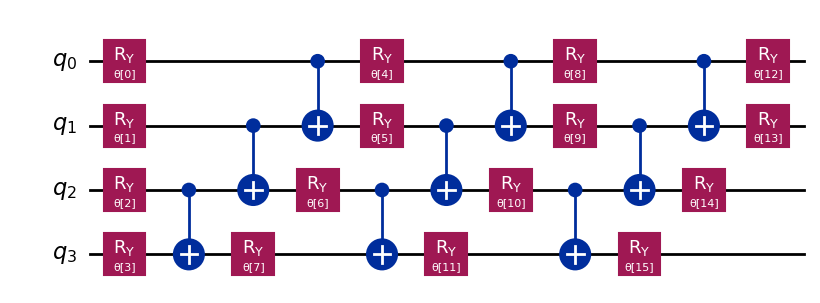

In [4]:
ansatz.decompose().draw("mpl", scale=1)

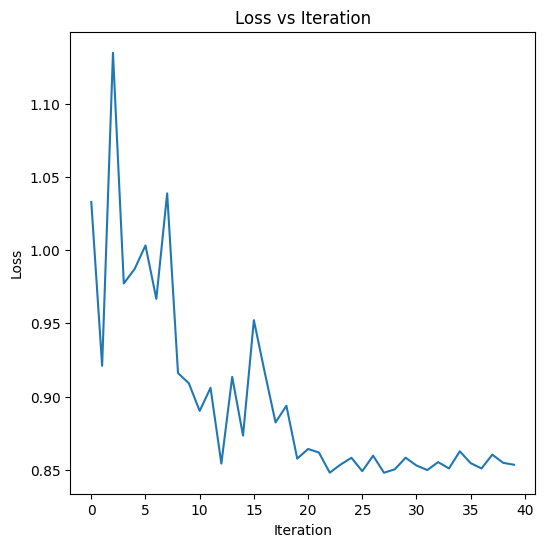

Training time: 20 seconds
Quantum VQC Train: 0.73
Quantum VQC Test : 0.65


In [ ]:
#THIS IS PCA EXAMPLE (given more time, can remove PCA and just use 4 features for VQC)

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler
from IPython.display import clear_output
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# reduce 4 features to 2 features
pca = PCA(n_components=2)

features_2d = pca.fit_transform(features)

plt.rcParams["figure.figsize"] = (6, 6)

sns.scatterplot(
    x=features_2d[:, 0],
    y=features_2d[:, 1],
    hue=labels,
    palette="tab10"
)
plt.title("PCA Projection (2D)")
plt.show()


train_features, test_features, train_labels, test_labels = train_test_split(
    features_2d,
    labels,
    train_size=0.8,
    random_state=123,
    stratify=labels,
)

from sklearn.svm import SVC

svc = SVC(class_weight="balanced")
svc.fit(train_features, train_labels)

print("Classical SVM Train:", svc.score(train_features, train_labels))
print("Classical SVM Test :", svc.score(test_features, test_labels))

# Classical SVM metrics (PCA 2D)
preds_train_cls = svc.predict(train_features)
preds_test_cls = svc.predict(test_features)
print("\nClassical SVM Metrics (Train - PCA 2D):")
print(classification_report(train_labels, preds_train_cls, zero_division=0))
print("\nClassical SVM Metrics (Test - PCA 2D):")
print(classification_report(test_labels, preds_test_cls, zero_division=0))


num_features = train_features.shape[1]

feature_map = ZZFeatureMap(feature_dimension=num_features, reps=1)
ansatz = RealAmplitudes(num_qubits=num_features, reps=3)
optimizer = COBYLA(maxiter=40)
sampler = StatevectorSampler()

objective_func_vals = []

def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.plot(objective_func_vals)
    plt.title("Loss vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()

vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback_graph,
)

import time

start = time.time()

vqc.fit(train_features, train_labels)

elapsed = time.time() - start

print(f"Training time: {round(elapsed)} seconds")

train_score_q = vqc.score(train_features, train_labels)
test_score_q = vqc.score(test_features, test_labels)

print(f"Quantum VQC Train: {train_score_q:.2f}")
print(f"Quantum VQC Test : {test_score_q:.2f}")
